# 📌 Importação de bibliotecas

In [1]:
import numpy as np
import pandas as pd

In [2]:
from typing import Union

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [5]:
from scipy.stats import f_oneway
from scipy.stats import levene
from scipy import stats
import pingouin as pg

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from yellowbrick.model_selection import FeatureImportances

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_percentage_error
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report
from yellowbrick.classifier import ClassificationReport
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve
)

In [7]:
import copy

In [8]:
import warnings

## Importação de pacotes locais

In [9]:
import scripts.local_tools as lt
import scripts.telecomx_analysis as ta
import scripts.telecomx_machine_learning as tml

## Configurações do ambiente

In [10]:
pd.set_option('display.max_columns', None)

In [11]:
warnings.simplefilter(action='ignore', category=FutureWarning)

## Constantes

In [12]:
NUM_SEMENTE_ALEATORIA = 42
TAMANHO_TESTE = 0.3
MAXIMO_ITERACAO = 1000

In [13]:
LIST_SCORING = ['accuracy','recall', 'precision', 'f1']

# 📌 Extração de dados

In [14]:
df_dados = pd.read_csv('./dados/dados_tratados.csv')

In [15]:
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customerID                    7043 non-null   object 
 1   Churn                         7043 non-null   int64  
 2   customer_gender               7043 non-null   object 
 3   customer_SeniorCitizen        7043 non-null   int64  
 4   customer_Partner              7043 non-null   int64  
 5   customer_Dependents           7043 non-null   int64  
 6   customer_tenure               7043 non-null   int64  
 7   phone_PhoneService            7043 non-null   int64  
 8   phone_MultipleLines           7043 non-null   int64  
 9   internet_InternetService      7043 non-null   int64  
 10  internet_OnlineSecurity       7043 non-null   int64  
 11  internet_OnlineBackup         7043 non-null   int64  
 12  internet_DeviceProtection     7043 non-null   int64  
 13  int

In [16]:
df_dados.nunique()

customerID                      7043
Churn                              2
customer_gender                    2
customer_SeniorCitizen             2
customer_Partner                   2
customer_Dependents                2
customer_tenure                   72
phone_PhoneService                 2
phone_MultipleLines                2
internet_InternetService           2
internet_OnlineSecurity            2
internet_OnlineBackup              2
internet_DeviceProtection          2
internet_TechSupport               2
internet_StreamingTV               2
internet_StreamingMovies           2
account_Contract                   3
account_PaperlessBilling           2
account_PaymentMethod              4
account_Charges_Monthly         1585
account_Charges_Total           6534
internet_Service_Description       3
customer_tenure_bins               6
account_Charges_Monthly_bins       6
account_Charges_Total_bins        13
account_Contract_Monthly           2
additional_InternetService         7
o

Verificar dados duplicados

In [17]:
df_dados.duplicated().sum()

0

# 📌 Tratamento de dados

In [18]:
df_ohe = tml.df_final_modelo_v1(df_dados)

# 📌 Seleção e validação dos modelos de treinamento

## Tabela de verificação de padronização dos dados

| Modelo                 | Precisa padronizar? | Tipo de padronização (se necessário)   |
| ---------------------- | ------------------- | -------------------------------------- |
| DecisionTreeClassifier | ❌ Não               | —                                      |
| LogisticRegression     | ✅ Sim               | `StandardScaler` (média 0, desvio 1)   |
| RandomForest           | ❌ Não               | —                                      |
| XGBoost                | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| LightGBM               | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| CatBoost               | ❌ Não               | —                                      |


## Conceitos sobre as métricas de um modelo

Aqui está o quadro comparativo para churn (evasão de clientes), considerando que a classe positiva é “cliente vai sair”:

| **Métrica**                | **O que mede**                                                                     | **Quando valor é alto**                                        | **Risco quando valor é baixo**                                   | **Custo de erro associado**                                                |
| -------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Precisão (Precision)**   | Entre todos que o modelo previu como “vai sair”, qual porcentagem realmente saiu   | Você gasta retenção apenas em quem de fato sairia              | Gastar recursos em retenção de clientes que iam ficar (FP alto)  | **Custo financeiro** com campanhas desnecessárias (descontos, bônus, etc.) |
| **Recall (Sensibilidade)** | Entre todos que realmente saíram, qual porcentagem o modelo previu como “vai sair” | Você identifica a maior parte dos clientes que iam sair        | Deixar escapar clientes que saem (FN alto)                       | **Perda de receita** e potencial perda de market share                     |
| **F1-Score**               | Média harmônica de precisão e recall                                               | Equilíbrio entre acertar quem vai sair e evitar falsos alarmes | Ou alto custo de retenção inútil ou perda de clientes — ou ambos | **Equilíbrio financeiro e estratégico** — custo total menor                |
| **FP (Falso Positivo)**    | Previu saída, mas o cliente ficaria                                                | —                                                              | Gastar para reter quem não ia sair                               | Desperdício de budget de retenção                                          |
| **FN (Falso Negativo)**    | Previu permanência, mas o cliente saiu                                             | —                                                              | Não agir para reter quem realmente sairia                        | Perda direta de receita + possível impacto na reputação                    |
    

📌 Resumo visual da prioridade

    Se retenção for muito cara → priorizar alta precisão.

    Se perder clientes for muito prejudicial → priorizar alto recall.

    Se quer balancear ambos → otimizar F1-Score.

## Split base de dados em train e test

In [19]:
X = df_ohe.drop(columns=['Churn'])

In [20]:
y = df_ohe.Churn

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = NUM_SEMENTE_ALEATORIA, test_size=TAMANHO_TESTE, stratify=y)

## Treinamento do Modelo - DecisionTreeClassifier

In [22]:
model_dtc = DecisionTreeClassifier(random_state=NUM_SEMENTE_ALEATORIA)
model_dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [23]:
print(f'Acurácia Decision Tree - Treinamento: {model_dtc.score(X_train, y_train)*100:.2f}%')
print(f'Acurácia Decision Tree - Teste: {model_dtc.score(X_test, y_test)*100:.2f}%')

Acurácia Decision Tree - Treinamento: 88.90%
Acurácia Decision Tree - Teste: 75.30%


In [24]:
model_dtc = DecisionTreeClassifier(max_depth=10, random_state=NUM_SEMENTE_ALEATORIA)
model_dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [25]:
print(f'Acurácia Decision Tree - Treinamento: {model_dtc.score(X_train, y_train)*100:.2f}%')
print(f'Acurácia Decision Tree - Teste: {model_dtc.score(X_test, y_test)*100:.2f}%')

Acurácia Decision Tree - Treinamento: 83.23%
Acurácia Decision Tree - Teste: 77.52%


In [26]:
y_pred_dtc = model_dtc.predict(X_test)

In [27]:
y_pred_proba_dtc = model_dtc.predict_proba(X_test)

### Matriz de confusão

In [28]:
matriz_confusao = confusion_matrix(y_true = y_test, y_pred = y_pred_dtc)

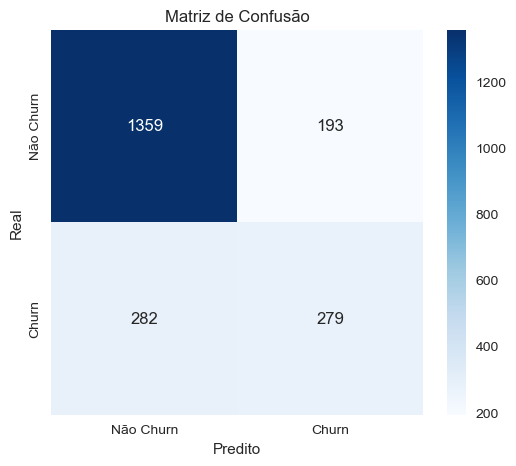

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Churn','Churn'], yticklabels=['Não Churn','Churn'])
plt.ylabel('Real')
plt.xlabel('Predito')
plt.title('Matriz de Confusão')
plt.show()

In [30]:
list_df = []
colunas_binarias = lt.identify_columns_binary_values(X_test)
for c in colunas_binarias:
    list_df.append(tml.df_specific_confusion_matrix(X_test, y_test, y_pred_dtc, c))
df_independent = pd.concat(list_df, axis=0)

df_independent

E:\Local_Drive\Cursos Livres\ONE\06-Estatística e Machine Learning G8 - ONE\08-Challenge Telecom X - análise de evasão de clientes - Parte 2\TelecomX_parte2_BR\scripts\telecomx_machine_learning.py:253: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = (2 * precision * recall) / (precision + recall)


,filter_value,support,accuracy,negative predictive value,precision,recall,f1-score,TN,FP,FN,TP
customer_SeniorCitizen,1,349,0.704871,0.728507,0.664062,0.586207,0.622711,161,43,60,85
customer_Partner,1,1032,0.809109,0.856018,0.517483,0.366337,0.428986,761,69,128,74
customer_Dependents,1,616,0.819805,0.876364,0.348485,0.252747,0.292994,482,43,68,23
phone_MultipleLines,1,883,0.761042,0.825949,0.597610,0.576923,0.587084,522,101,110,150
account_PaperlessBilling,1,1213,0.740313,0.806452,0.609337,0.613861,0.611591,650,159,156,248
account_Contract_Monthly,1,1182,0.663283,0.702364,0.602592,0.565923,0.583682,505,184,214,279
internet_Service_Description_DSL,1,753,0.795485,0.846970,0.430108,0.283688,0.341880,559,53,101,40
internet_Service_Description_Fiber_optic,1,897,0.681159,0.713193,0.636364,0.613402,0.624672,373,136,150,238
charges_total_bin__inf_96_62_,1,242,0.640496,0.632812,0.649123,0.611570,0.629787,81,40,47,74
charges_total_bin__1182_80_3273_68_,1,564,0.780142,0.819127,0.554217,0.345865,0.425926,394,37,87,46


### Curva ROC

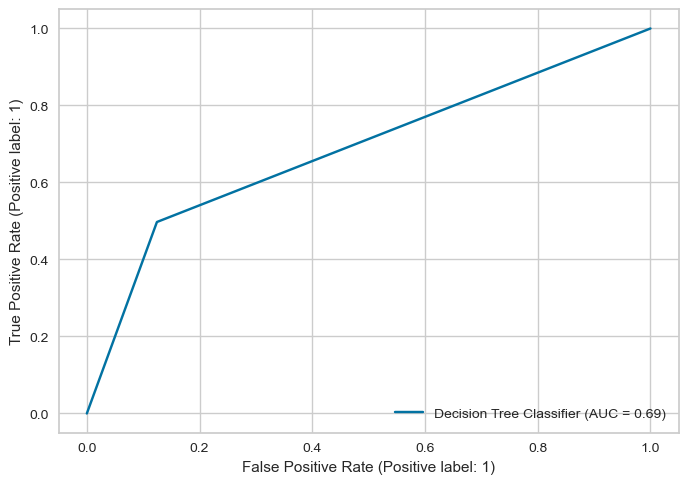

In [31]:
RocCurveDisplay.from_predictions(y_true = y_test, y_pred = y_pred_dtc, name = 'Decision Tree Classifier');

In [32]:
print(f'ROC AUC: {roc_auc_score(y_test, y_pred_dtc):.4f}')

ROC AUC: 0.6865


### Curva de precisão x recall

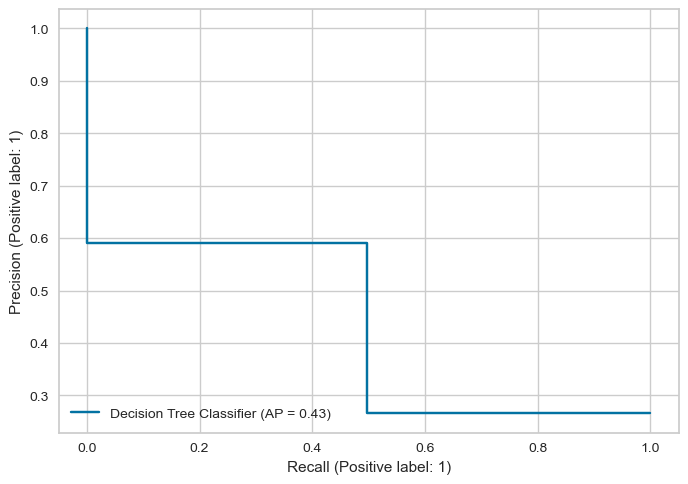

In [33]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred_dtc, name = 'Decision Tree Classifier');

In [34]:
print(f'Precisão média: {average_precision_score(y_test, y_pred_dtc):.6f}')

Precisão média: 0.427430


### Relatório de métricas

In [35]:
tml.df_classifier_metrics(y_test, y_pred_dtc, y_pred_proba_dtc, ['DecisionTree'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
DecisionTree,0.775201,0.591102,0.497326,0.540174,0.773888,2113,1359,193,282,279


Métricas:
Acurácia: 0.7752
Precisão: 0.5911
Recall: 0.4973
F1-Score: 0.5402
ROC AUC: 0.7739

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1552
           1       0.59      0.50      0.54       561

    accuracy                           0.78      2113
   macro avg       0.71      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113


Matrix de confusão:

[[1359  193]
 [ 282  279]]


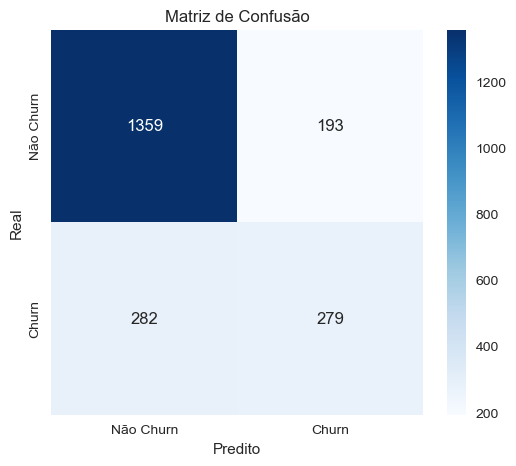

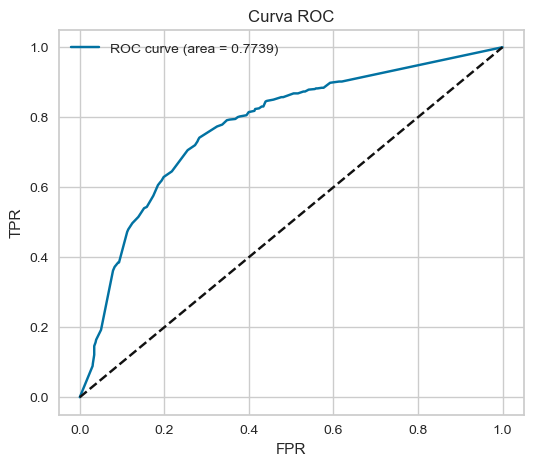

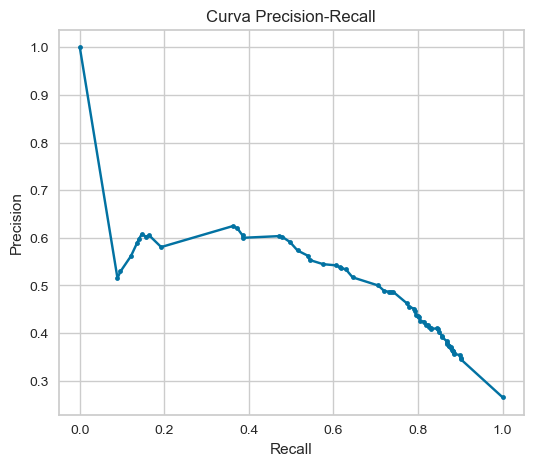

In [36]:
tml.avaliar_modelo(y_test, y_pred_dtc, y_pred_proba_dtc)

📊 1. Métricas principais (agregadas)

| Métrica      | Valor  | Interpretação                                                                                                                |
| ------------ | ------ | ---------------------------------------------------------------------------------------------------------------------------- |
| **Acurácia** | 0.7547 | O modelo acerta \~75,5% das previsões no total.                                                                              |
| **Precisão** | 0.5323 | Quando o modelo prevê "classe 1", ele acerta \~53,2% das vezes.                                                              |
| **Recall**   | 0.5022 | O modelo consegue identificar \~50,2% dos verdadeiros positivos (classe 1).                                                  |
| **F1-Score** | 0.5168 | Harmonia entre precisão e recall: equilíbrio razoável, mas ainda abaixo do ideal.                                            |
| **ROC AUC**  | 0.7439 | Boa separação entre classes. Indica que o modelo está aprendendo a distinguir as classes (quanto mais próximo de 1, melhor). |


🧾 2. Relatório de Classificação

Este relatório apresenta métricas separadas para cada classe:

Classe 0 (sem churn, por exemplo):

    Precisão: 0.83 → Quando o modelo diz que um cliente vai ficar (classe 0), ele acerta 83% das vezes.

    Recall: 0.84 → De todos os clientes que realmente ficaram, ele identificou 84%.

    F1-score: 0.84 → Excelente desempenho na classe 0.

Classe 1 (com churn):

    Precisão: 0.53 → Quando o modelo prevê churn, acerta 53% das vezes.

    Recall: 0.50 → De todos os que realmente deram churn, detecta apenas metade.

    F1-score: 0.52 → Baixo desempenho comparado à classe 0.

    ⚠️ O modelo está desequilibrado: ele funciona melhor para a classe 0 do que para a classe 1, que geralmente é a mais importante em casos de churn.

🔢 3. Matriz de Confusão

Legenda:

    1098 = Verdadeiros Negativos (VN): previu 0, era 0 → acerto

    203 = Falsos Positivos (FP): previu 1, era 0 → erro

    229 = Falsos Negativos (FN): previu 0, era 1 → erro

    231 = Verdadeiros Positivos (VP): previu 1, era 1 → acerto

Interpretação:

    Erros em classe 1 (churn) são significativos:

        229 casos o modelo falhou em prever o churn (falsos negativos)

        Isso é crítico, pois você perde a chance de agir para reter esses clientes.

📌 Conclusão

| Categoria                  | Avaliação                                                                                                |
| -------------------------- | -------------------------------------------------------------------------------------------------------- |
| **Desempenho geral**       | Mediano. Boa acurácia, mas mascarada por desequilíbrio entre classes.                                    |
| **Classe majoritária (0)** | Excelente desempenho.                                                                                    |
| **Classe minoritária (1)** | Desempenho fraco. O modelo **perde metade dos casos reais** de churn.                                    |
| **ROC AUC = 0.7439**       | Indica que o modelo **tem potencial**, mas precisa de ajustes para melhorar recall/precisão na classe 1. |


### Validação Cruzada Estratificada

Como a variável target está desbalanceada, utilizar StratifiedKFold

In [37]:
skf = StratifiedKFold(n_splits= 5 ,shuffle= True, random_state= NUM_SEMENTE_ALEATORIA)
cv_resultados = cross_validate(model_dtc, X, y, cv = skf, scoring=LIST_SCORING)

In [38]:
for ls in LIST_SCORING:
    teste_ls = f'test_{ls}'
    print('')
    tml.intervalo_conf(cv_resultados, teste_ls)


Tipo de teste: test_accuracy
Média: 0.7795
Desvio padrão: 0.0037
Intervalo de confiança entre: 0.7722 e 0.7868

Tipo de teste: test_recall
Média: 0.5029
Desvio padrão: 0.0475
Intervalo de confiança entre: 0.4080 e 0.5979

Tipo de teste: test_precision
Média: 0.6014
Desvio padrão: 0.0070
Intervalo de confiança entre: 0.5875 e 0.6154

Tipo de teste: test_f1
Média: 0.5464
Desvio padrão: 0.0271
Intervalo de confiança entre: 0.4921 e 0.6007


### Balanceamento de dados

#### Pipeline para validação Oversampling

In [39]:
pipeline_dtc = imbpipeline([
    ('oversample', SMOTE(random_state=NUM_SEMENTE_ALEATORIA)),
    ('DTC', model_dtc),
])

In [40]:
skf = StratifiedKFold(n_splits= 5, shuffle= True, random_state= NUM_SEMENTE_ALEATORIA)
cv_resultados = cross_validate(pipeline_dtc, X, y, cv= skf, scoring= LIST_SCORING)

In [41]:
for ls in LIST_SCORING:
    teste_ls = f'test_{ls}'
    print('')
    tml.intervalo_conf(cv_resultados, teste_ls)


Tipo de teste: test_accuracy
Média: 0.7226
Desvio padrão: 0.0084
Intervalo de confiança entre: 0.7058 e 0.7393

Tipo de teste: test_recall
Média: 0.7357
Desvio padrão: 0.0274
Intervalo de confiança entre: 0.6809 e 0.7904

Tipo de teste: test_precision
Média: 0.4850
Desvio padrão: 0.0103
Intervalo de confiança entre: 0.4645 e 0.5056

Tipo de teste: test_f1
Média: 0.5845
Desvio padrão: 0.0143
Intervalo de confiança entre: 0.5560 e 0.6130


#### Pipeline para validação Undersampling

In [42]:
pipeline_dtc = imbpipeline([
    ('undersample', NearMiss(version= 3)),
    ('DTC', model_dtc)
])

In [43]:
skf = StratifiedKFold(n_splits= 5, shuffle= True, random_state= NUM_SEMENTE_ALEATORIA)
cv_resultados = cross_validate(pipeline_dtc, X, y, cv= skf, scoring= LIST_SCORING)

C:\ProgramData\anaconda3\Lib\site-packages\imblearn\under_sampling\_prototype_selection\_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\imblearn\under_sampling\_prototype_selection\_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\imblearn\under_sampling\_prototype_selection\_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\imblearn\under_sampling\_prototype_selection\_nearmiss.py:206: UserWa

In [44]:
for ls in LIST_SCORING:
    teste_ls = f'test_{ls}'
    print('')
    tml.intervalo_conf(cv_resultados, teste_ls)


Tipo de teste: test_accuracy
Média: 0.7288
Desvio padrão: 0.0048
Intervalo de confiança entre: 0.7193 e 0.7383

Tipo de teste: test_recall
Média: 0.6137
Desvio padrão: 0.0441
Intervalo de confiança entre: 0.5256 e 0.7018

Tipo de teste: test_precision
Média: 0.4911
Desvio padrão: 0.0072
Intervalo de confiança entre: 0.4768 e 0.5055

Tipo de teste: test_f1
Média: 0.5450
Desvio padrão: 0.0194
Intervalo de confiança entre: 0.5061 e 0.5839


In [45]:
cv_resultados

{'fit_time': array([0.3320837 , 0.18492889, 0.18548322, 0.1693027 , 0.20051408]),
 'score_time': array([0.01562524, 0.03125119, 0.01562285, 0.01565385, 0.        ]),
 'test_accuracy': array([0.73527324, 0.73243435, 0.72391767, 0.72940341, 0.72301136]),
 'test_recall': array([0.63368984, 0.62834225, 0.67647059, 0.57908847, 0.55080214]),
 'test_precision': array([0.50105708, 0.49682875, 0.48560461, 0.49090909, 0.48130841]),
 'test_f1': array([0.5596222 , 0.55489965, 0.56536313, 0.53136531, 0.51371571])}

#### Pipeline para validação Oversampling com Decision Tree Classifier

O balanceamento de Oversampling apresentou melhor resultado que Undersampling

In [46]:
pipeline_over_dtc = imbpipeline([
    ('oversample', SMOTE(random_state=NUM_SEMENTE_ALEATORIA)),
    ('DTC', model_dtc),
])

In [47]:
pipeline_over_dtc.fit(X_train, y_train)

Pipeline(steps=[('oversample', SMOTE(random_state=42)),
                ('DTC', DecisionTreeClassifier(max_depth=10, random_state=42))])

In [48]:
y_pred_over_dtc = pipeline_over_dtc.predict(X_test)

In [49]:
y_pred_proba_over_dtc = pipeline_over_dtc.predict_proba(X_test)

### Relatório de métricas

In [50]:
tml.df_classifier_metrics(y_test, y_pred_over_dtc, y_pred_proba_over_dtc, ['DecisioinTree - Oversample'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
DecisioinTree - Oversample,0.716517,0.478889,0.768271,0.590007,0.772716,2113,1083,469,130,431


Métricas:
Acurácia: 0.7165
Precisão: 0.4789
Recall: 0.7683
F1-Score: 0.5900
ROC AUC: 0.7727

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.89      0.70      0.78      1552
           1       0.48      0.77      0.59       561

    accuracy                           0.72      2113
   macro avg       0.69      0.73      0.69      2113
weighted avg       0.78      0.72      0.73      2113


Matrix de confusão:

[[1083  469]
 [ 130  431]]


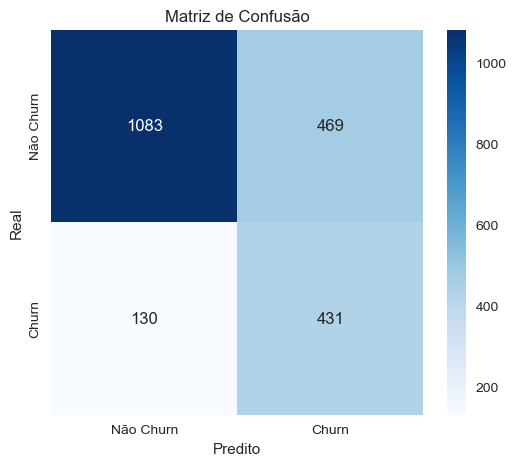

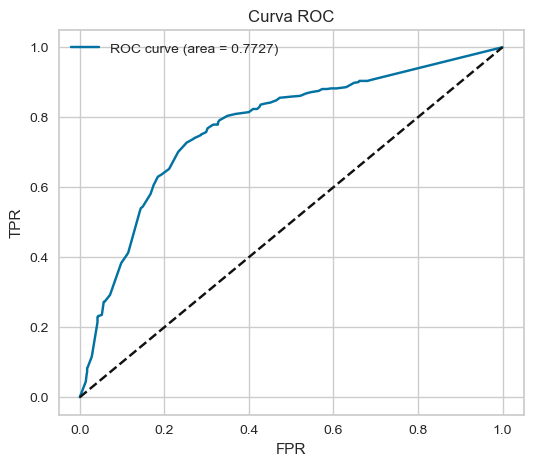

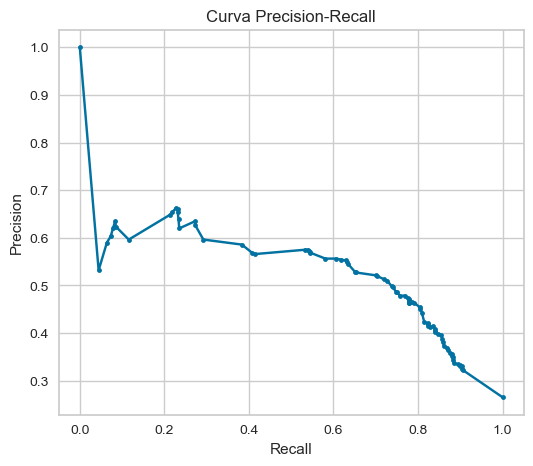

In [51]:
tml.avaliar_modelo(y_test, y_pred_over_dtc, y_pred_proba_over_dtc)

In [52]:
model_dtc = DecisionTreeClassifier(max_depth=10, random_state=NUM_SEMENTE_ALEATORIA)
model_dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


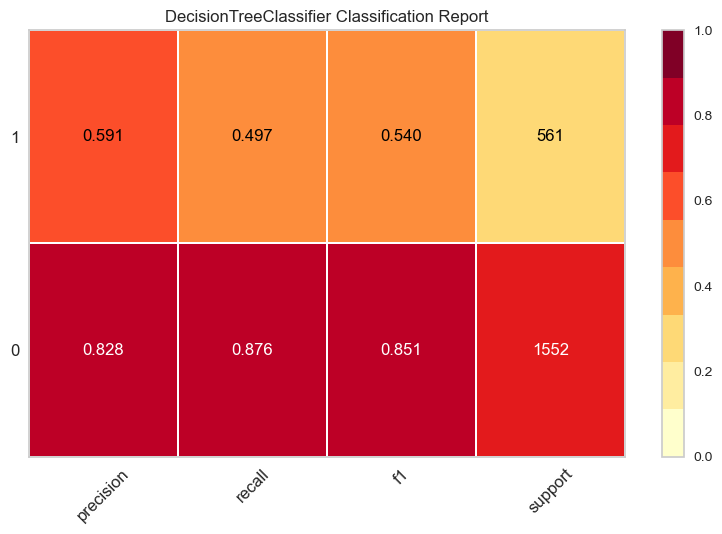

In [53]:
tml.plotar_classification_report(model_dtc, X_train, y_train, X_test, y_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


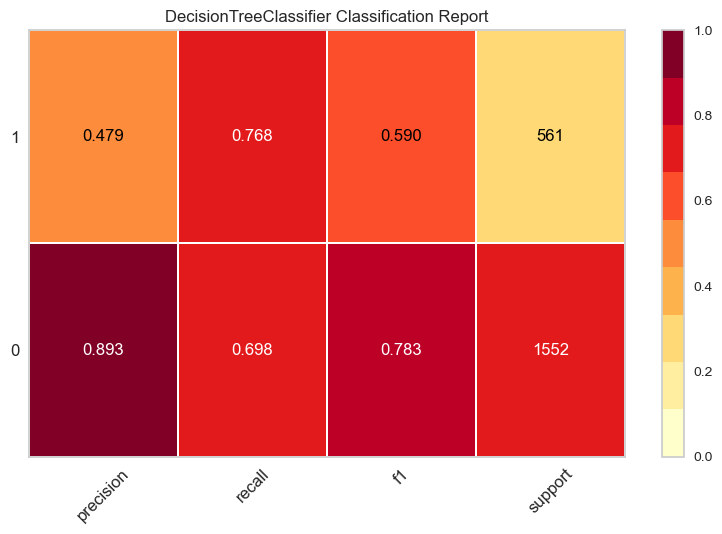

In [54]:
tml.plotar_classification_report(pipeline_over_dtc, X_train, y_train, X_test, y_test)

## Seleção de recursos

### Identificando importância das features

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


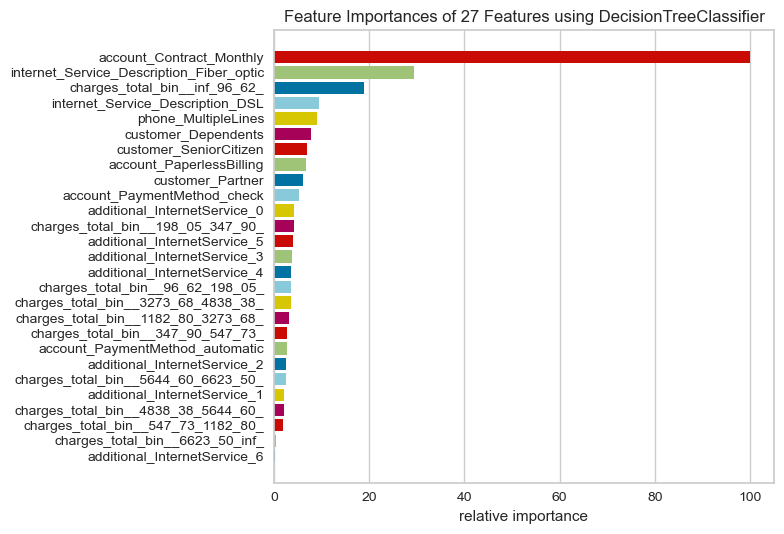

In [55]:
viz = FeatureImportances(copy.deepcopy(model_dtc))
viz.fit(X_train, y_train)
viz.show();

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


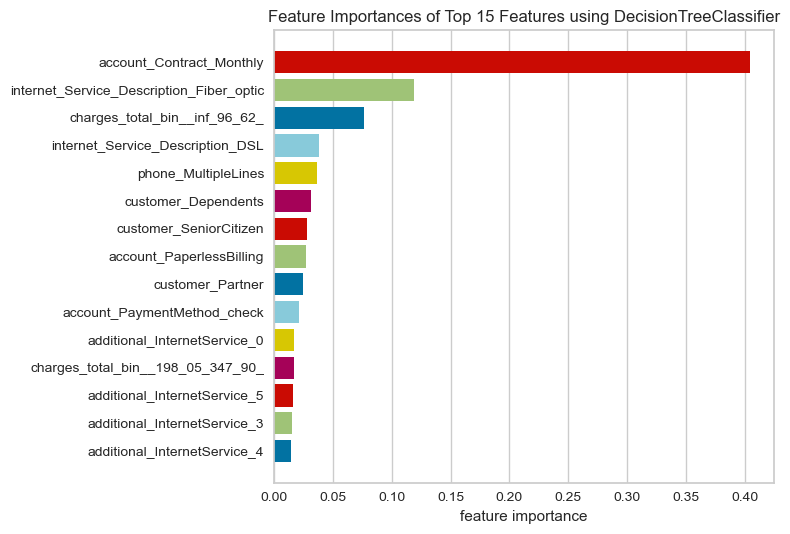

In [56]:
viz = FeatureImportances(copy.deepcopy(model_dtc), relative=False, topn=15)
viz.fit(X_train, y_train)
viz.show();

In [57]:
df_importance = tml.df_feature_importances(model_dtc, base_100=True)

In [58]:
df_importance

,Feature,Importances,Importance_Cumulative
0,account_Contract_Monthly,40.459917,40.459917
1,internet_Service_Description_Fiber_optic,11.923617,52.383534
2,charges_total_bin__inf_96_62_,7.657539,60.041073
3,internet_Service_Description_DSL,3.854471,63.895545
4,phone_MultipleLines,3.694690,67.590235
5,customer_Dependents,3.144670,70.734905
6,customer_SeniorCitizen,2.794180,73.529085
7,account_PaperlessBilling,2.742999,76.272084
8,customer_Partner,2.473101,78.745185
9,account_PaymentMethod_check,2.130385,80.875570


### Analisando metricas do modelo de acordo com as features selecionadas

In [59]:
tml.df_result_selected_features(df_importance, model_dtc, X_train, y_train, X_test, y_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,1,5,10,15,20,25,27
accuracy,0.734501,0.766682,0.767629,0.761477,0.776148,0.774728,0.775201
precision,0.000000,0.567729,0.593583,0.571429,0.598655,0.588358,0.591489
recall,0.000000,0.508021,0.395722,0.406417,0.475936,0.504456,0.495544
f1,0.000000,0.536218,0.474866,0.475000,0.530288,0.543186,0.539282
roc_auc,0.717422,0.808248,0.794679,0.771118,0.781185,0.774441,0.773849
support,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
True Negative,1552.000000,1335.000000,1400.000000,1381.000000,1373.000000,1354.000000,1360.000000
False Positive,0.000000,217.000000,152.000000,171.000000,179.000000,198.000000,192.000000
False Negative,561.000000,276.000000,339.000000,333.000000,294.000000,278.000000,283.000000
True Positive,0.000000,285.000000,222.000000,228.000000,267.000000,283.000000,278.000000


In [60]:
tml.df_result_selected_features(df_importance, model_dtc, X_train, y_train, X_test, y_test, init_result=20, end_result=25, step_result=1)

,20,21,22,23,24,25
accuracy,0.776148,0.774728,0.778041,0.775201,0.773781,0.774728
precision,0.598655,0.592998,0.598712,0.592275,0.590022,0.588358
recall,0.475936,0.483066,0.497326,0.491979,0.484848,0.504456
f1,0.530288,0.532417,0.543330,0.537488,0.532290,0.543186
roc_auc,0.781185,0.773892,0.775354,0.775352,0.778051,0.774441
support,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
True Negative,1373.000000,1366.000000,1365.000000,1362.000000,1363.000000,1354.000000
False Positive,179.000000,186.000000,187.000000,190.000000,189.000000,198.000000
False Negative,294.000000,290.000000,282.000000,285.000000,289.000000,278.000000
True Positive,267.000000,271.000000,279.000000,276.000000,272.000000,283.000000


In [61]:
tml.df_result_selected_features(df_importance, pipeline_over_dtc, X_train, y_train, X_test, y_test)

,1,5,10,15,20,25,27
accuracy,0.641742,0.689541,0.712731,0.703739,0.704212,0.714150,0.716990
precision,0.417090,0.454106,0.474099,0.462601,0.464444,0.475145,0.479330
recall,0.878788,0.837790,0.750446,0.716578,0.745098,0.732620,0.764706
f1,0.565691,0.588972,0.581090,0.562238,0.572211,0.576438,0.589286
roc_auc,0.717422,0.807623,0.790639,0.768157,0.777946,0.762558,0.772479
support,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
True Negative,863.000000,987.000000,1085.000000,1085.000000,1070.000000,1098.000000,1086.000000
False Positive,689.000000,565.000000,467.000000,467.000000,482.000000,454.000000,466.000000
False Negative,68.000000,91.000000,140.000000,159.000000,143.000000,150.000000,132.000000
True Positive,493.000000,470.000000,421.000000,402.000000,418.000000,411.000000,429.000000


In [62]:
tml.df_result_selected_features(df_importance, pipeline_over_dtc, X_train, y_train, X_test, y_test, init_result=20, end_result=25, step_result=1)

,20,21,22,23,24,25
accuracy,0.704212,0.698060,0.709418,0.707525,0.713204,0.714150
precision,0.464444,0.458015,0.469852,0.467577,0.474747,0.475145
recall,0.745098,0.748663,0.736185,0.732620,0.754011,0.732620
f1,0.572211,0.568336,0.573611,0.570833,0.582645,0.576438
roc_auc,0.777946,0.773051,0.776793,0.767818,0.777289,0.762558
support,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
True Negative,1070.000000,1055.000000,1086.000000,1084.000000,1084.000000,1098.000000
False Positive,482.000000,497.000000,466.000000,468.000000,468.000000,454.000000
False Negative,143.000000,141.000000,148.000000,150.000000,138.000000,150.000000
True Positive,418.000000,420.000000,413.000000,411.000000,423.000000,411.000000


### Treinamento DecisionTreeClassifier - Selecionando features

In [63]:
selected_features = df_importance.Feature.values[:22]

In [64]:
X_selected = X[selected_features]

In [65]:
X_selected.columns

Index(['account_Contract_Monthly', 'internet_Service_Description_Fiber_optic',
       'charges_total_bin__inf_96_62_', 'internet_Service_Description_DSL',
       'phone_MultipleLines', 'customer_Dependents', 'customer_SeniorCitizen',
       'account_PaperlessBilling', 'customer_Partner',
       'account_PaymentMethod_check', 'additional_InternetService_0',
       'charges_total_bin__198_05_347_90_', 'additional_InternetService_5',
       'additional_InternetService_3', 'additional_InternetService_4',
       'charges_total_bin__96_62_198_05_',
       'charges_total_bin__3273_68_4838_38_',
       'charges_total_bin__1182_80_3273_68_',
       'charges_total_bin__347_90_547_73_', 'account_PaymentMethod_automatic',
       'additional_InternetService_2', 'charges_total_bin__5644_60_6623_50_'],
      dtype='object')

### Criando novas bases de treino e teste com as features selecionadas

In [66]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, random_state=NUM_SEMENTE_ALEATORIA, test_size=TAMANHO_TESTE, stratify=y)

In [67]:
model_sel_dtc = DecisionTreeClassifier(max_depth=10, random_state=NUM_SEMENTE_ALEATORIA)
model_sel_dtc.fit(X_train_sel, y_train_sel)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [68]:
y_sel_pred_dtc = model_sel_dtc.predict(X_test_sel)
y_sel_pred_proba_dtc = model_sel_dtc.predict_proba(X_test_sel)

In [69]:
pipeline_over_sel_dtc = imbpipeline([
    ('oversample', SMOTE(random_state=NUM_SEMENTE_ALEATORIA)),
    ('DTC', model_sel_dtc),
])

In [70]:
pipeline_over_sel_dtc.fit(X_train_sel, y_train_sel)

Pipeline(steps=[('oversample', SMOTE(random_state=42)),
                ('DTC', DecisionTreeClassifier(max_depth=10, random_state=42))])

In [71]:
y_sel_pred_over_dtc = pipeline_over_sel_dtc.predict(X_test_sel)
y_sel_pred_proba_over_dtc = pipeline_over_sel_dtc.predict_proba(X_test_sel)

### Relatório de métricas

In [72]:
tml.df_classifier_metrics(y_test_sel, y_sel_pred_dtc, y_sel_pred_proba_dtc, ['DecisionTree - Selected Feature'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
DecisionTree - Selected Feature,0.778041,0.598712,0.497326,0.54333,0.775354,2113,1365,187,282,279


In [73]:
tml.df_classifier_metrics(y_test_sel, y_sel_pred_over_dtc, y_sel_pred_proba_over_dtc, ['DecisionTree - Oversample - Selected Feature'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
DecisionTree - Oversample - Selected Feature,0.709418,0.469852,0.736185,0.573611,0.776793,2113,1086,466,148,413


Métricas:
Acurácia: 0.7780
Precisão: 0.5987
Recall: 0.4973
F1-Score: 0.5433
ROC AUC: 0.7754

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1552
           1       0.60      0.50      0.54       561

    accuracy                           0.78      2113
   macro avg       0.71      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113


Matrix de confusão:

[[1365  187]
 [ 282  279]]


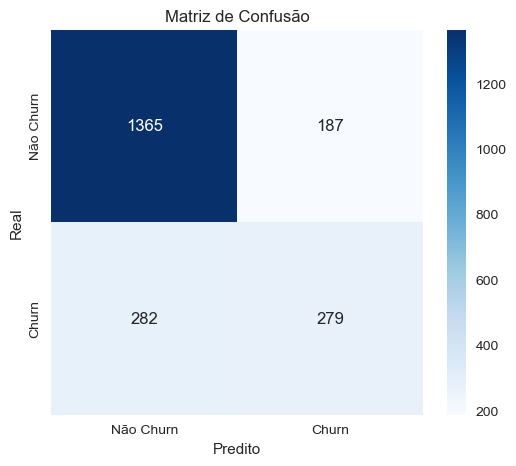

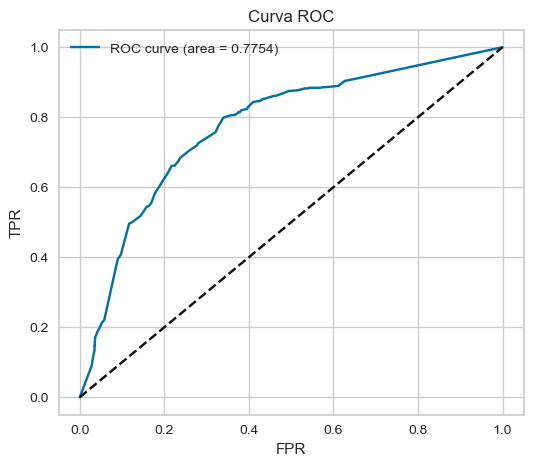

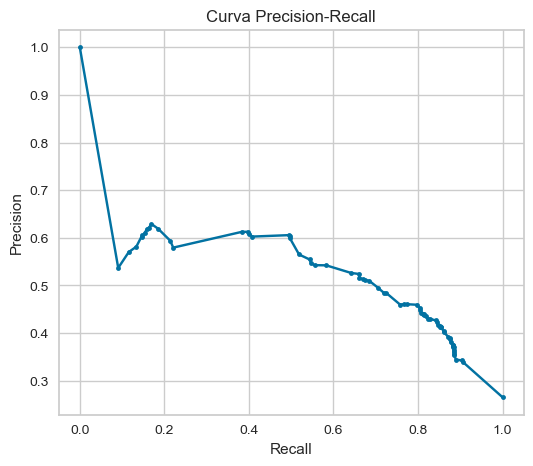

In [74]:
tml.avaliar_modelo(y_test_sel, y_sel_pred_dtc, y_sel_pred_proba_dtc)

Métricas:
Acurácia: 0.7094
Precisão: 0.4699
Recall: 0.7362
F1-Score: 0.5736
ROC AUC: 0.7768

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      1552
           1       0.47      0.74      0.57       561

    accuracy                           0.71      2113
   macro avg       0.67      0.72      0.68      2113
weighted avg       0.77      0.71      0.72      2113


Matrix de confusão:

[[1086  466]
 [ 148  413]]


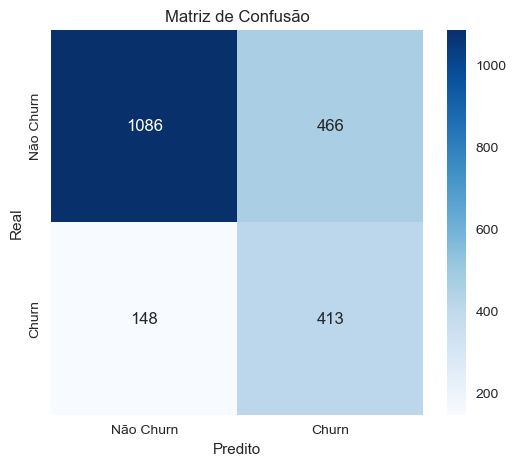

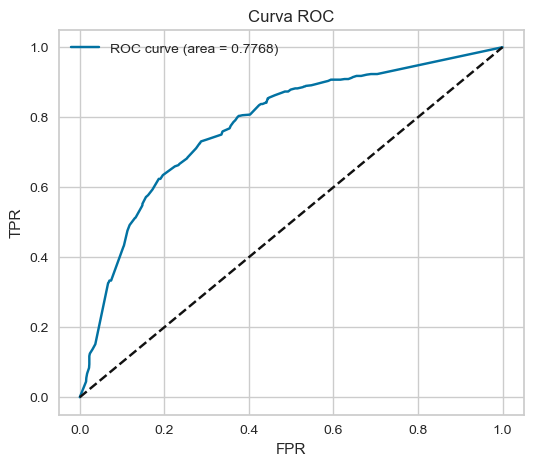

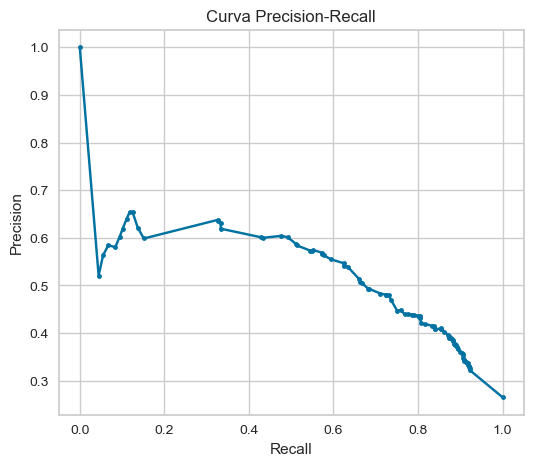

In [75]:
tml.avaliar_modelo(y_test_sel, y_sel_pred_over_dtc, y_sel_pred_proba_over_dtc)

### Consolidação das métricas

In [80]:
df_metricas = []

df_metricas.append(tml.df_classifier_metrics(y_test, y_pred_dtc, y_pred_proba_dtc, ['DecisionTree']))

df_metricas.append(tml.df_classifier_metrics(y_test, y_pred_over_dtc, y_pred_proba_over_dtc, ['DecisioinTree - Oversample']))

df_metricas.append(tml.df_classifier_metrics(y_test_sel, y_sel_pred_dtc, y_sel_pred_proba_dtc, ['DecisionTree - Selected Feature']))

df_metricas.append(tml.df_classifier_metrics(y_test_sel, y_sel_pred_over_dtc, y_sel_pred_proba_over_dtc, ['DecisionTree - Oversample - Selected Feature']))

df_metricas = pd.concat(df_metricas, axis=0)
df_metricas

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
DecisionTree,0.775201,0.591102,0.497326,0.540174,0.773888,2113,1359,193,282,279
DecisioinTree - Oversample,0.716517,0.478889,0.768271,0.590007,0.772716,2113,1083,469,130,431
DecisionTree - Selected Feature,0.778041,0.598712,0.497326,0.543330,0.775354,2113,1365,187,282,279
DecisionTree - Oversample - Selected Feature,0.709418,0.469852,0.736185,0.573611,0.776793,2113,1086,466,148,413


In [38]:
df_metricas.to_clipboard()